### 1. CLIP for zero-shot Image Classification

#### Importing Required Libraries

In [1]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image

p:\Projects\MultiModal_LLMs\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Loading the Model and Processor

In [2]:
# Load the CLIP model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch16")

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 24559.49it/s]


#### Load the Image and define text classes

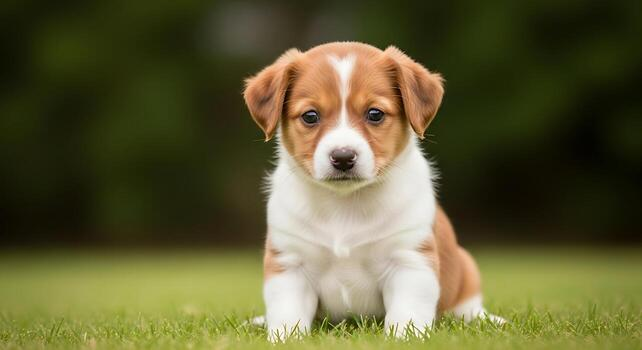

In [3]:
# Load the image 
image = Image.open("images/dog.png")

image

In [4]:
# define the text classes 
classes = ["a photo of a cat", "a photo of a dog", "a photo of a car"]

#### Pass Image and text to CLIP

In [5]:
# pass image and text through the processor
inputs = processor(images=image, text=classes, return_tensors="pt", padding=True) 

print(inputs)

{'pixel_values': tensor([[[[-1.1207, -1.1207, -1.1207,  ..., -1.2521, -1.2521, -1.2521],
          [-1.1207, -1.1207, -1.1207,  ..., -1.2521, -1.2521, -1.2521],
          [-1.1207, -1.1207, -1.1207,  ..., -1.2375, -1.2375, -1.2375],
          ...,
          [ 0.2807,  0.2515,  0.2077,  ...,  0.4413,  0.4997,  0.5727],
          [ 0.2953,  0.2515,  0.2661,  ...,  0.4267,  0.4997,  0.5581],
          [ 0.3683,  0.3245,  0.3537,  ...,  0.3975,  0.4705,  0.5289]],

         [[-0.9567, -0.9567, -0.9567,  ..., -1.0317, -1.0317, -1.0317],
          [-0.9567, -0.9567, -0.9567,  ..., -1.0317, -1.0317, -1.0317],
          [-0.9567, -0.9567, -0.9567,  ..., -1.0167, -1.0167, -1.0167],
          ...,
          [ 0.5291,  0.4841,  0.4540,  ...,  0.6041,  0.6792,  0.7242],
          [ 0.4991,  0.4691,  0.4991,  ...,  0.5891,  0.6642,  0.7092],
          [ 0.5741,  0.5291,  0.5441,  ...,  0.5591,  0.6341,  0.6792]],

         [[-1.3238, -1.3238, -1.3238,  ..., -1.3949, -1.3949, -1.3949],
          [-1

In [6]:
# pass inputs through the model
outputs = model(**inputs) # "**" -> unpack the dictionary into keyword arguments

In [7]:
outputs

CLIPOutput(loss=None, logits_per_image=tensor([[22.9505, 29.4033, 21.4221]], grad_fn=<TBackward0>), logits_per_text=tensor([[22.9505],
        [29.4033],
        [21.4221]], grad_fn=<MulBackward0>), text_embeds=tensor([[ 0.0413, -0.0037,  0.0096,  ...,  0.0059, -0.0040,  0.0131],
        [ 0.0282, -0.0117,  0.0112,  ..., -0.0110,  0.0240,  0.0283],
        [-0.0188, -0.0297,  0.0262,  ...,  0.0232, -0.0246,  0.0147]],
       grad_fn=<DivBackward0>), image_embeds=tensor([[ 4.0536e-02, -9.0934e-02, -7.4667e-03,  1.1958e-02,  1.6075e-02,
         -1.4480e-02, -1.5335e-02,  7.3098e-02, -5.2969e-03, -6.0094e-02,
          1.1853e-02, -3.3883e-02,  3.8318e-02, -1.5039e-02, -2.5078e-02,
          3.7503e-02, -1.8163e-02, -9.6532e-03, -3.3974e-02, -2.9109e-02,
         -2.1238e-02, -2.5894e-02,  7.3390e-03, -3.6506e-02, -1.0713e-02,
          1.3273e-02,  8.8519e-03,  7.5360e-03, -3.2470e-02,  2.5596e-02,
         -6.4065e-03,  4.1491e-03, -5.9524e-03,  1.9329e-02, -8.8804e-03,
          4.446

#### Convert Image logits to Probs 

In [8]:
# Image-text similarity scores 
logits_per_image = outputs.logits_per_image # this is the image-text similarity score

print(logits_per_image)

tensor([[22.9505, 29.4033, 21.4221]], grad_fn=<TBackward0>)


In [9]:
# convert logits to probabilities via softmax
probs = logits_per_image.softmax(dim=1) # dim=1 -> softmax across the text classes
print(probs)

tensor([[1.5732e-03, 9.9809e-01, 3.4119e-04]], grad_fn=<SoftmaxBackward0>)


In [10]:
# print the predicted class 
predicted_class = classes[probs.argmax()] # get the index of the highest probability and map to class 
print(f"Predicted class: {predicted_class} with probability {probs.max().item():.4f}")

Predicted class: a photo of a dog with probability 0.9981


#### Different Classes Prediction (Classification)

Modular function

In [11]:
def predict_clip(classes, image=None):
    if image is None:
        image = globals().get("image")
        if image is None:
            raise ValueError("Please provide an image or define a variable named 'image'.")

    inputs = processor(images=image, text=classes, return_tensors="pt", padding=True)
    outputs = model(**inputs)

    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1)

    predicted_index = probs.argmax(dim=1).item()
    predicted_class = classes[predicted_index]
    predicted_prob = probs.max().item()

    print(f"Predicted class: {predicted_class} with probability {predicted_prob:.4f}")

Classes: Ugly cat or cute cat using same image

In [12]:
classes = ["ugly cat", "cute cat"]

predict_clip(classes)

Predicted class: cute cat with probability 0.9835


Classes: cat meme or not a cat meme using same image

In [13]:
classes = ["cat meme", "not a cat meme"]

predict_clip(classes)

Predicted class: not a cat meme with probability 0.9932


Classes: cat meme or not a cat meme using different image

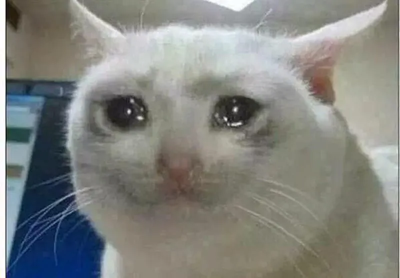

In [14]:
image = Image.open("images/cat_meme.png")

# resize in-place keeping aspect ratio (max width/height 400)
image.thumbnail((400, 400))

# display
image

In [15]:
classes = ["cat meme", "not a cat meme"] 


predict_clip(classes, image=image)

Predicted class: cat meme with probability 0.7075


### 2. CLIP for Image Search 

Load Images

In [16]:
# create list of images to search over 
image_name_list  = ["images/dog.png", "images/duck.png", "images/cat.png"]

image_list = [] 

for image_name in image_name_list:
    image_list.append(Image.open(image_name))

Define query and process inputs

In [21]:
# define a query 
query = "a cute dog" 

# pass images and query to CLIP 
inputs = processor(images=image_list, text=query, return_tensors="pt", padding=True)

In [24]:
inputs

{'pixel_values': tensor([[[[-1.1207e+00, -1.1207e+00, -1.1207e+00,  ..., -1.2521e+00,
           -1.2521e+00, -1.2521e+00],
          [-1.1207e+00, -1.1207e+00, -1.1207e+00,  ..., -1.2521e+00,
           -1.2521e+00, -1.2521e+00],
          [-1.1207e+00, -1.1207e+00, -1.1207e+00,  ..., -1.2375e+00,
           -1.2375e+00, -1.2375e+00],
          ...,
          [ 2.8071e-01,  2.5152e-01,  2.0772e-01,  ...,  4.4130e-01,
            4.9969e-01,  5.7268e-01],
          [ 2.9531e-01,  2.5152e-01,  2.6612e-01,  ...,  4.2670e-01,
            4.9969e-01,  5.5808e-01],
          [ 3.6830e-01,  3.2451e-01,  3.5371e-01,  ...,  3.9750e-01,
            4.7049e-01,  5.2889e-01]],

         [[-9.5669e-01, -9.5669e-01, -9.5669e-01,  ..., -1.0317e+00,
           -1.0317e+00, -1.0317e+00],
          [-9.5669e-01, -9.5669e-01, -9.5669e-01,  ..., -1.0317e+00,
           -1.0317e+00, -1.0317e+00],
          [-9.5669e-01, -9.5669e-01, -9.5669e-01,  ..., -1.0167e+00,
           -1.0167e+00, -1.0167e+00],
   

Compute Image probabilities

In [25]:
# compute logits and probabilities 
outputs = model(**inputs) 

# logits per text 
logits_per_text = outputs.logits_per_text 

print(logits_per_text)

tensor([[30.5085, 23.9186, 21.2555]], grad_fn=<MulBackward0>)


In [27]:
probs = logits_per_text.softmax(dim=1)

probs

tensor([[9.9853e-01, 1.3722e-03, 9.5683e-05]], grad_fn=<SoftmaxBackward0>)

Matching Probability: 0.9985


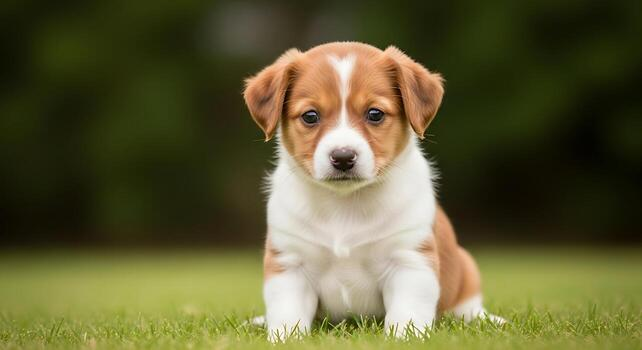

In [33]:
# print the best match 
best_match = image_list[probs.argmax()] 
prob_match = round(float(probs[0][probs.argmax()]), 4)

print("Matching Probability:", prob_match) 
display(best_match)

### Making it modular

In [34]:
def image_search(query, image_list):
    inputs = processor(images=image_list, text=query, return_tensors="pt", padding=True)
    outputs = model(**inputs)
    logits_per_text = outputs.logits_per_text
    probs = logits_per_text.softmax(dim=1)
    
    best_match_index = probs.argmax().item()
    best_match_image = image_list[best_match_index]
    best_match_prob = round(float(probs[0][best_match_index]), 4)

    print(f"Best match probability: {best_match_prob}")
    display(best_match_image)

Best match probability: 0.9945


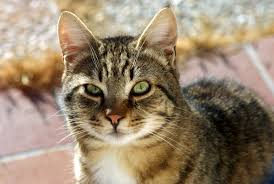

In [35]:
query = "a cute cat" 

image_search(query, image_list)

Best match probability: 0.9754


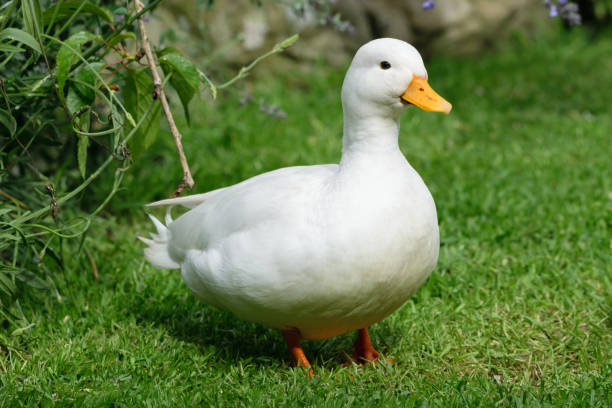

In [37]:
query = "a animal that fly, walk and swim" 

image_search(query, image_list)

Best match probability: 0.846


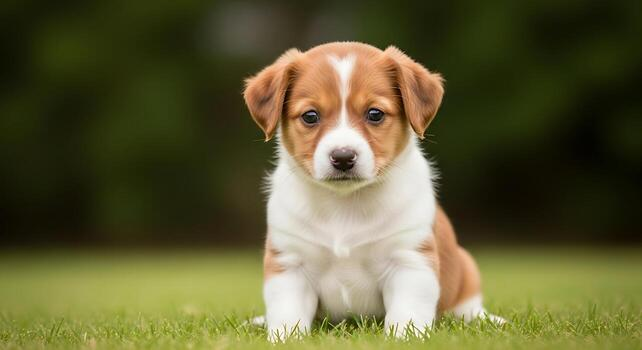

In [38]:
query = "a good boy" 

image_search(query, image_list)

Best match probability: 0.6792


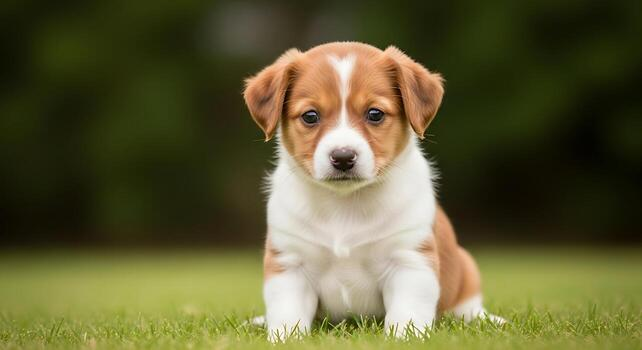

In [39]:
query = "the best pet in the world" 

image_search(query, image_list)